In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collecting data

In [ ]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


# Splitting Dataset

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, 
random_state=42, stratify=df["Category"])

# EDA

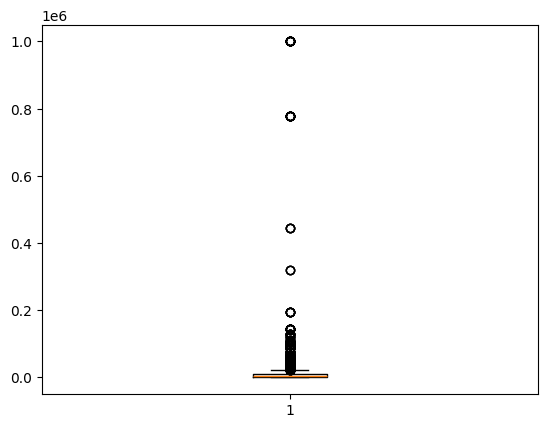

In [5]:
plt.boxplot(strat_train_set["Number Sold"])
plt.show()

In [6]:
threshold_90 = strat_train_set["Number Sold"].quantile(0.9)

In [7]:
count_top_10 = strat_train_set[strat_train_set["Number Sold"] > threshold_90].shape[0]
print(count_top_10)

427


In [8]:
threshold_80 = strat_train_set['Number Sold'].quantile(0.8)
print(threshold_80)

11200.0


In [9]:
count_top_20 = strat_train_set[strat_train_set['Number Sold'] > threshold_80].shape[0]
print(count_top_20)

861


Kuantil 80% dari Number Sold yaitu 11100.0 akan dijadikan threshold penjualan banyak. 
Dikarenakan terdapat lebih banyak produk yang melebihi kuantil tersebut, dan dapat dibilang ini adalah kesuksesan umum untuk suatu produk


In [10]:
threshold = threshold_80

# Feature Engineering

In [11]:
def add_top_product_feature(data, threshold):
    df_copy = data.copy() 
    df_copy['is_top_product'] = ((df_copy['Overall Rating'] > 4) & (df_copy['Number Sold'] > threshold)).astype(int)
    return df_copy

strat_train_set = add_top_product_feature(strat_train_set, threshold_80)
strat_test_set = add_top_product_feature(strat_test_set, threshold_80)

print(strat_train_set['is_top_product'].value_counts())

is_top_product
0    3459
1     861
Name: count, dtype: int64


# EDA

In [12]:
corr_matrix = strat_train_set.corr(numeric_only=True)
corr_matrix["is_top_product"].sort_values(ascending=False)

is_top_product     1.000000
Total Review       0.566726
Number Sold        0.332390
Overall Rating     0.055727
Price             -0.105363
Customer Rating   -0.156919
Name: is_top_product, dtype: float64

<Axes: xlabel='is_top_product', ylabel='Price'>

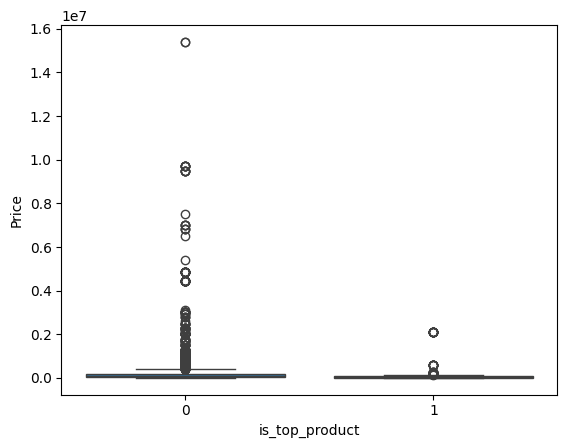

In [13]:
sns.boxplot(data=strat_train_set, x="is_top_product", y="Price")
# plt.boxplot(x=strat_train_set["is_top_product"], y=)
# strat_train_set["is_top_product"].boxplot()

produk yang memiliki atribut is_top_product 1, harganya lebih murah daripada produk yang memiliki atribut is_top_product 0, kesimpulannya adalah semakin kecil Price maka semakin besar jumlah pembelinya. Ini sebagai justifikasi penggunaan kolom price karena pada cell sebelumnya, dapat dilihat bahwa price memiliki korelasi negatif.

<Axes: xlabel='Price', ylabel='is_top_product'>

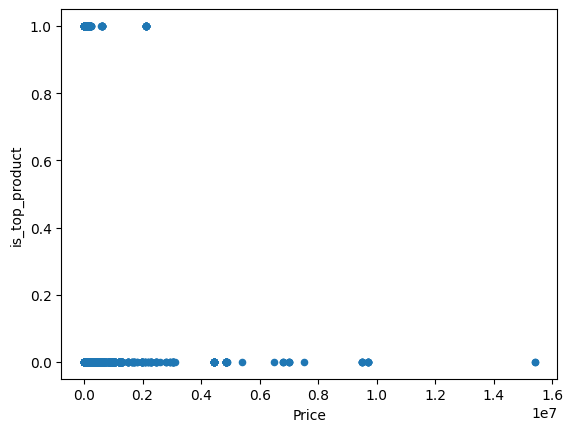

In [14]:
strat_train_set.plot(kind="scatter", x="Price", y="is_top_product")

<Axes: >

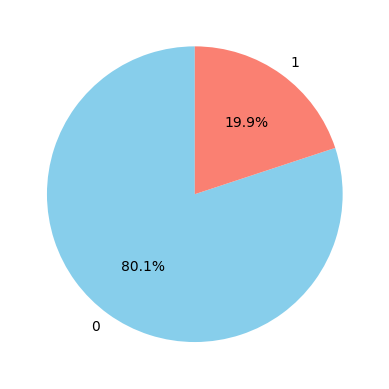

In [15]:
counts = strat_train_set['is_top_product'].value_counts()

# Plot as pie
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])

selisih dari rasio nilai target besar, artinya data ini memiliki imbalance

# Data Preprocessing

In [16]:
import copy

In [17]:
df = copy.deepcopy(strat_train_set)
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion,is_top_product
4201,Kids and Baby Fashion,Masker ANAK ANAK 3 ply isi 50pcs kids 3-14thn ...,Jakarta Utara,9000,4.9,15200,1727,4,Harga murah kualitas baik,Positive,Happy,1
4055,Kitchen,Tefal Cook & Clean Frypan 24cm Wajan Anti Lengket,Kab. Tangerang,359000,4.9,3890,2113,2,gampang penyok,Negative,Sadness,0
1474,Party Supplies and Craft,Balon LED RGB LENGKAP 2/BOBO LED/Balon Lampu T...,Jakarta Barat,7900,4.8,19800,1298,3,gak nyala padahal batt udah baru. anak sy jd k...,Negative,Sadness,1
1309,Body Care,Dove Body Wash Deeply Nourishing Refill 850 Ml,Kab. Tangerang,72300,5.0,9695,3399,1,"BELI PEPSODENT PAKET 4 PCS TAPI YG DIKIRIM 2, ...",Negative,Anger,0
2917,Men's Fashion,"PIERRE CARDIN SHORTY 2IN1 PC268-2 - RANDOM, M",Jakarta Barat,149000,4.9,1413,706,4,Sesuai deskripsi..Packingnya rapi..Thanks,Positive,Happy,0


In [18]:
df = copy.deepcopy(strat_train_set)
df = df.drop(["Number Sold", "Overall Rating", "Customer Review", "Sentiment", 
              "Emotion", "Total Review", "Customer Rating", "Product Name"], axis=1)

df_labels = df["is_top_product"]
df = df.drop("is_top_product", axis=1)

Menghapus kolom yang memiliki korelasi rendah, dan kolom-kolom yang tidak berhubungan dengan input untuk model inference nanti, seperti produk baru tidak mungkin memiliki customer rating dan jumlah penjualan. 

In [19]:
df.head()

,Category,Location,Price
4201,Kids and Baby Fashion,Jakarta Utara,9000
4055,Kitchen,Kab. Tangerang,359000
1474,Party Supplies and Craft,Jakarta Barat,7900
1309,Body Care,Kab. Tangerang,72300
2917,Men's Fashion,Jakarta Barat,149000


In [20]:
strat_test_set = strat_test_set.drop(["Number Sold", "Overall Rating", "Customer Review", "Sentiment", 
              "Emotion", "Total Review", "Customer Rating", "Product Name"], axis=1)


In [21]:
strat_test_set.head()

,Category,Location,Price,is_top_product
3395,Phones and Tablets,Jakarta Pusat,150000,0
651,Office & Stationery,Kab. Tangerang,23000,0
1955,Other Products,Kab. Bandung,60500,0
4355,Muslim Fashion,Kab. Kediri,27000,0
2649,Electronics,Jakarta Utara,2499000,0


In [22]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC

In [23]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(), ["Category", "Location"])
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [24]:
df = preprocessor.fit_transform(df)
strat_test_set = preprocessor.fit_transform(strat_test_set)

In [25]:
smotenc = SMOTENC(categorical_features=[0, 1], random_state=42)
df_resampled, df_labels_resampled = smotenc.fit_resample(df, df_labels)   

In [26]:
print(f"Original shape: {df.shape}")
print(f"Resampled shape: {df_resampled.shape}")

Original shape: (4320, 3)
Resampled shape: (6918, 3)


# Training

In [27]:
from sklearn.ensemble import RandomForestClassifier


In [28]:
clf = RandomForestClassifier(random_state=42)
clf.fit(df_resampled, df_labels_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
pred = clf.predict(df_resampled)
print(pred[:5])
print()
print(df_labels_resampled[:5])

[1 0 1 0 0]

0    1
1    0
2    1
3    0
4    0
Name: is_top_product, dtype: int64


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df_labels_resampled, pred)
print("Confusion Matrix:\n", cm)

report = classification_report(df_labels_resampled, pred, target_names=['Unfit', 'Fit'])
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[3443   16]
 [  11 3448]]

Classification Report:
               precision    recall  f1-score   support

       Unfit       1.00      1.00      1.00      3459
         Fit       1.00      1.00      1.00      3459

    accuracy                           1.00      6918
   macro avg       1.00      1.00      1.00      6918
weighted avg       1.00      1.00      1.00      6918



# Fine Tuning

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline

In [32]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("random_forest", RandomForestClassifier(random_state=42))
])

In [33]:

param_dist = { 
    'random_forest__max_features': randint(low=1, high=10),              
}

rnd_search = RandomizedSearchCV(
    full_pipeline, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3,
    scoring='neg_root_mean_squared_error', 
    random_state=42
)

rnd_search.fit(df_resampled, df_labels_resampled)

c:\Users\lenovo\Documents\GitHub\tubes_SGML_computing\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\lenovo\Documents\GitHub\tubes_SGML_computing\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\lenovo\Documents\GitHub\tubes_SGML_computing\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenovo\Documents\GitHub\tubes_SGML_computing\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
     

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'random_forest__max_features': <scipy.stats....002D3EBC8D550>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [34]:
final_model = rnd_search.best_estimator_

In [35]:
pred = final_model.predict(df_resampled)
print(pred[:5])
print()
print(df_labels_resampled[:5])

[1 0 1 0 0]

0    1
1    0
2    1
3    0
4    0
Name: is_top_product, dtype: int64


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df_labels_resampled, pred)
print("Confusion Matrix:\n", cm)

report = classification_report(df_labels_resampled, pred, target_names=['Unfit', 'Fit'])
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[3443   16]
 [  11 3448]]

Classification Report:
               precision    recall  f1-score   support

       Unfit       1.00      1.00      1.00      3459
         Fit       1.00      1.00      1.00      3459

    accuracy                           1.00      6918
   macro avg       1.00      1.00      1.00      6918
weighted avg       1.00      1.00      1.00      6918



# Evaluate

In [37]:
strat_test_set.head()

,Category,Location,Price,is_top_product
3395,22.0,4.0,150000,0
651,19.0,23.0,23000,0
1955,20.0,10.0,60500,0
4355,18.0,14.0,27000,0
2649,8.0,7.0,2499000,0


In [38]:
X_test = strat_test_set.drop("is_top_product", axis=1)
y_test = copy.copy(strat_test_set.iloc[:, -1])

In [39]:
X_test.head()


,Category,Location,Price
3395,22.0,4.0,150000
651,19.0,23.0,23000
1955,20.0,10.0,60500
4355,18.0,14.0,27000
2649,8.0,7.0,2499000


In [40]:
y_test.head()

3395    0
651     0
1955    0
4355    0
2649    0
Name: is_top_product, dtype: int64

In [41]:
pred = final_model.predict(X_test)

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:\n", cm)

report = classification_report(y_test, pred, target_names=['Unfit', 'Fit'])
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[832  39]
 [ 47 162]]

Classification Report:
               precision    recall  f1-score   support

       Unfit       0.95      0.96      0.95       871
         Fit       0.81      0.78      0.79       209

    accuracy                           0.92      1080
   macro avg       0.88      0.87      0.87      1080
weighted avg       0.92      0.92      0.92      1080



# Save Model

In [43]:
import joblib

joblib.dump(final_model, "e-commerce_analysis_classification_model.pkl")

['e-commerce_analysis_classification_model.pkl']